# Project 5 — Natural Language Processing

This notebook solves all three parts of the NLP project:

1. **Part 1** — Load the CSV of famous people. Pick a reference person and find the 10 whose
   overview text is most similar (NLP-wise). Also report the reference person's sentiment.
2. **Part 2** — Use the Wikipedia API to pull full articles for the reference person and the
   10 neighbors, re-rank by similarity on the *full* articles, and compare the two rankings.
3. **Part 3** — Make it interactive: choose or type a name and see the 10 closest people.

*Comments are written so that someone reading this cold in six months — including me — can
follow what each cell does, why it exists, and what output to expect.*

## Setup — installs and imports

In [1]:
# ONE-TIME SETUP (per Colab session). Re-run after a fresh runtime.
# - textblob: sentiment analysis + corpora
# - wikipedia-api: pull full Wikipedia article text in Part 2
# - ipywidgets: the interactive dropdown/textbox in Part 3 (usually preinstalled on Colab)
# %%capture hides the long, noisy install log.
%%capture
!pip install -q -U textblob wikipedia-api ipywidgets
!python -m textblob.download_corpora


In [2]:
# --- Imports (run once per session) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from textblob import TextBlob                                   # sentiment of overview text
from sklearn.feature_extraction.text import TfidfVectorizer     # turn text into number vectors
from sklearn.neighbors import NearestNeighbors                  # find the closest overviews

import wikipediaapi                                             # Part 2: full article text

pd.options.display.max_columns = 100   # don't truncate wide DataFrames


## Settings
All the knobs in one place (named constants instead of magic numbers scattered around).

In [3]:
# --- Project settings (change these, not the code below) ---

# Where the data lives.
CSV_URL = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"

# >>> SET THIS <<< The person you build the project around. Must match a name in the
# CSV's 'name' column exactly (the names come from DBpedia). Leave the quotes, put a
# name between them, e.g. "Barack Obama". Use the partial-name search cell in Part 1
# if you're unsure of the exact spelling.
REFERENCE_NAME = "Barack Obama"        # <-- type your chosen person's name here

# How many similar people to return.
N_NEIGHBORS = 10

# Wikipedia API needs a user-agent string identifying your project (their policy).
WIKI_USER_AGENT = "cnm-ds-project5-nlp"

# Friendly guard: stop early with a clear message if the name wasn't filled in.
if REFERENCE_NAME.strip() == "":
    raise ValueError("Please set REFERENCE_NAME above to a person's name before running on.")


# Part 1 — CSV data: nearest people + sentiment

**Goal:** pick a reference person, output the 10 people whose overview text is closest, and
report the reference person's sentiment.

### Load the data

In [4]:
# Read the CSV straight from the URL. Columns are: URI, name, text
#   URI  = DBpedia link (we mostly ignore it)
#   name = the person's name
#   text = a short overview paragraph about them
# EXPECT roughly 42,000+ rows.
people = pd.read_csv(CSV_URL)
print('rows, columns:', people.shape)
people.head()


rows, columns: (42786, 3)


,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


In [5]:
# Quick health check: column names, types, and any missing values.
people.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


In [6]:
# Drop any rows with a missing overview, since we can't compare empty text.
# reset_index(drop=True) renumbers rows 0,1,2,... so row positions line up cleanly
# with the TF-IDF matrix and neighbor indices later (avoids index-mismatch bugs).
people = people.dropna(subset=['text']).reset_index(drop=True)
print('rows after dropping blank overviews:', len(people))


rows after dropping blank overviews: 42786


### Confirm the reference person is in the data

In [7]:
# Find the row number (position) of our reference person by exact name match.
# We use this position to pull their vector out of the TF-IDF matrix below.
#
# If the name isn't found, this raises a clear error telling you to fix
# REFERENCE_NAME (better than a confusing crash later).
matches = people.index[people['name'] == REFERENCE_NAME].tolist()
if len(matches) == 0:
    raise ValueError(
        f"'{REFERENCE_NAME}' not found in the data. "
        "Check spelling/capitalization or try people[people['name'].str.contains('...')]."
    )
ref_idx = matches[0]               # row position of the reference person
print('Reference person:', REFERENCE_NAME)
print('Found at row index:', ref_idx)


Reference person: Barack Obama
Found at row index: 35811


In [8]:
# Helpful when REFERENCE_NAME isn't found: search for partial matches.
# (Change the search string to whoever you're looking for.)
# EXAMPLE: people[people['name'].str.contains('Obama', case=False, na=False)]
people[people['name'].str.contains('Obama', case=False, na=False)]


,URI,name,text
2936,<http://dbpedia.org/resource/Ricardo_Mangue_Ob...,Ricardo Mangue Obama Nfubea,ricardo mangue obama nfubea born c 1961 is a p...
35811,<http://dbpedia.org/resource/Barack_Obama>,Barack Obama,barack hussein obama ii brk husen bm born augu...


### Vectorize the overviews with TF-IDF

In [9]:
# Turn every overview into a numeric vector with TF-IDF.
#   - TF-IDF gives high weight to words that are distinctive to a person and
#     low weight to words common to everyone, so 'closeness' reflects meaningful
#     overlap rather than shared filler words.
#   - stop_words='english' drops common filler ('the','and','of',...).
#   - max_features caps the vocabulary size so the matrix stays manageable on
#     40k+ documents (top 20,000 most informative words is plenty).
# EXPECT a sparse matrix shaped (num_people, vocabulary_size).
vectorizer = TfidfVectorizer(stop_words='english', max_features=20000)
tfidf = vectorizer.fit_transform(people['text'])
print('TF-IDF matrix shape (people, words):', tfidf.shape)


TF-IDF matrix shape (people, words): (42786, 20000)


### Find the 10 nearest people

In [10]:
# Fit NearestNeighbors on the TF-IDF vectors.
#   metric='cosine' compares the ANGLE between text vectors, which is the
#   standard, length-independent way to measure document similarity (a long
#   overview and a short one can still be 'close' in topic).
# Fitting just stores the points for fast lookup; no real training happens.
nn = NearestNeighbors(metric='cosine').fit(tfidf)


In [11]:
# Ask for the reference person's nearest neighbors.
# We request N_NEIGHBORS + 1 because the closest match will be the person
# THEMSELVES (distance 0); we drop that so we return 10 OTHER people.
#
#   distances -> cosine distance to each neighbor (0 = identical, 1 = unrelated)
#   indices   -> row positions of those neighbors in `people`
distances, indices = nn.kneighbors(tfidf[ref_idx], n_neighbors=N_NEIGHBORS + 1)

# Flatten the 1-row results to plain 1-D arrays for easy handling.
distances = distances[0]
indices = indices[0]

# Drop the reference person themselves (the first entry, distance ~0).
neighbor_idx = indices[1:]
neighbor_dist = distances[1:]
print('Neighbor row positions:', neighbor_idx)


Neighbor row positions: [24478 38370  2412 38708 24837 18827 40178  6796  7914  4032]


In [12]:
# Build a tidy results table of the 10 closest people, nearest first.
#   'rank'      -> 1..10 (1 = most similar)
#   'distance'  -> cosine distance (smaller = more similar)
# This is the Part 1 deliverable: the 10 closest overviews to the reference.
part1_results = pd.DataFrame({
    'rank': range(1, N_NEIGHBORS + 1),
    'name': people.loc[neighbor_idx, 'name'].values,
    'distance': neighbor_dist.round(4),
})
part1_results


,rank,name,distance
0,1,Joe Biden,0.6551
1,2,Samantha Power,0.6911
2,3,Joe the Plumber,0.7069
3,4,Eric Stern (politician),0.7092
4,5,Leon Panetta,0.7232
5,6,Henry Waxman,0.7309
6,7,Chuck Hagel,0.7380
7,8,Eric Holder,0.7492
8,9,Phil Schiliro,0.7499
9,10,Kenneth D. Thompson,0.7625


### Sentiment of the reference person's overview

In [13]:
# TextBlob sentiment returns two numbers:
#   polarity:     -1.0 (negative) ... +1.0 (positive)
#   subjectivity:  0.0 (factual)  ... 1.0  (opinionated)
# Wikipedia-style overviews are usually fairly neutral/objective, so EXPECT a
# polarity near 0 and a low-to-moderate subjectivity.
ref_text = people.loc[ref_idx, 'text']
ref_sentiment = TextBlob(ref_text).sentiment

print('Sentiment of', REFERENCE_NAME, "'s overview:")
print('  polarity:    ', round(ref_sentiment.polarity, 4))
print('  subjectivity:', round(ref_sentiment.subjectivity, 4))


Sentiment of Barack Obama 's overview:
  polarity:     0.0787
  subjectivity: 0.2787


# Part 2 — Full Wikipedia articles: re-rank and compare

**Goal:** pull the *full* Wikipedia article for the reference person and each of the 10
neighbors, re-rank the neighbors by similarity on the full articles, then compare that
ranking to the Part 1 ranking (which used only the short overviews).

### Set up the Wikipedia client

In [14]:
# Create the Wikipedia API client. user_agent is REQUIRED by Wikipedia's policy.
# language='en' = English Wikipedia.
wiki = wikipediaapi.Wikipedia(user_agent=WIKI_USER_AGENT, language='en')

def get_wiki_text(name):
    '''Return the full plain text of a person's English Wikipedia page,
    or an empty string if the page doesn't exist. We look the page up by the
    person's name; if Wikipedia has no exact-title match, .exists() is False.'''
    page = wiki.page(name)
    if page.exists():
        return page.text
    return ''   # empty string -> handled gracefully downstream


### Part 2, Step 1 — print the reference person's Wikipedia text

In [15]:
# Pull the reference person's full article.
ref_wiki_text = get_wiki_text(REFERENCE_NAME)

# Articles can be very long, so print just the first 2000 characters as a check.
print('Article length (characters):', len(ref_wiki_text))
print('-' * 60)
print(ref_wiki_text[:2000])


Article length (characters): 85903
------------------------------------------------------------
Barack Hussein Obama II (born August 4, 1961) is an American politician who served as the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African American president. Obama previously served as a U.S. senator representing Illinois from 2005 to 2008 and as an Illinois state senator from 1997 to 2004.
Born in Honolulu, Obama graduated from Columbia University in 1983 with a Bachelor of Arts degree in political science and later worked as a community organizer in Chicago. In 1988, Obama enrolled in Harvard Law School, where he was the first Black president of the Harvard Law Review. He became a civil rights attorney and an academic, teaching constitutional law at the University of Chicago Law School from 1992 to 2004. In 1996, Obama was elected to represent the 13th district in the Illinois Senate, a position he held until 2004, when he s

### Part 2, Step 2 — sentiment of the full Wikipedia page

In [16]:
# Same TextBlob sentiment as Part 1, but on the FULL article rather than the
# short overview. EXPECT it to still be fairly neutral, possibly a little
# different from the overview's sentiment since there's much more text.
ref_wiki_sentiment = TextBlob(ref_wiki_text).sentiment
print('Sentiment of', REFERENCE_NAME, "'s full Wikipedia page:")
print('  polarity:    ', round(ref_wiki_sentiment.polarity, 4))
print('  subjectivity:', round(ref_wiki_sentiment.subjectivity, 4))


Sentiment of Barack Obama 's full Wikipedia page:
  polarity:     0.0987
  subjectivity: 0.3289


### Part 2, Step 3 — collect the 10 neighbors' Wikipedia articles

In [17]:
# Download the full article for each of the 10 neighbors.
# NOTE: this makes 10 live web requests, so it takes a few seconds. Some names
# may not resolve to an exact Wikipedia title -> those come back as '' and we
# flag them. We keep names + texts aligned in a small DataFrame.
neighbor_names = people.loc[neighbor_idx, 'name'].tolist()

neighbor_wiki_texts = []
for person_name in neighbor_names:
    article = get_wiki_text(person_name)
    neighbor_wiki_texts.append(article)
    # Show progress + whether each page was found (len 0 means not found).
    print(person_name, '-> article chars:', len(article))


Joe Biden -> article chars: 95761
Samantha Power -> article chars: 24362
Joe the Plumber -> article chars: 21563
Eric Stern (politician) -> article chars: 0
Leon Panetta -> article chars: 23495
Henry Waxman -> article chars: 14377
Chuck Hagel -> article chars: 44825
Eric Holder -> article chars: 57153
Phil Schiliro -> article chars: 2160
Kenneth D. Thompson -> article chars: 0


### Part 2, Step 4 — re-rank neighbors using the full articles

In [18]:
# Now measure similarity on the FULL articles instead of the short overviews.
# Strategy: vectorize [reference_article] + [the 10 neighbor articles] together
# with a fresh TF-IDF, then measure each neighbor's cosine distance to the
# reference (which sits at row 0).
#
# We build the document list with the reference FIRST, then the 10 neighbors.
wiki_docs = [ref_wiki_text] + neighbor_wiki_texts

# Fresh vectorizer for this smaller corpus (11 documents).
wiki_vectorizer = TfidfVectorizer(stop_words='english')
wiki_tfidf = wiki_vectorizer.fit_transform(wiki_docs)

# Cosine distance from the reference (row 0) to every document.
wiki_nn = NearestNeighbors(metric='cosine').fit(wiki_tfidf)
w_dist, w_idx = wiki_nn.kneighbors(wiki_tfidf[0], n_neighbors=len(wiki_docs))
w_dist = w_dist[0]
w_idx = w_idx[0]

# Map results back to names. Row 0 is the reference itself, so skip it.
# Remember: index 0 in wiki_docs = reference, indices 1..10 = the neighbors in
# the SAME order as neighbor_names.
wiki_ranking = []
for position, doc_index in enumerate(w_idx):
    if doc_index == 0:
        continue                      # skip the reference person themselves
    name = neighbor_names[doc_index - 1]   # -1 because neighbors start at doc index 1
    wiki_ranking.append((name, round(w_dist[position], 4)))

# Build a table ranked by full-article similarity (nearest first).
part2_results = pd.DataFrame(wiki_ranking, columns=['name', 'wiki_distance'])
part2_results['wiki_rank'] = range(1, len(part2_results) + 1)
part2_results


,name,wiki_distance,wiki_rank
0,Samantha Power,0.6102,1
1,Joe Biden,0.6882,2
2,Leon Panetta,0.7643,3
3,Joe the Plumber,0.7694,4
4,Phil Schiliro,0.7795,5
5,Chuck Hagel,0.8279,6
6,Eric Holder,0.8389,7
7,Henry Waxman,0.8724,8
8,Eric Stern (politician),1.0000,9
9,Kenneth D. Thompson,1.0000,10


### Part 2, Step 5 — compare the two rankings

In [19]:
# Merge the Part 1 (overview) ranking with the Part 2 (full-article) ranking
# on name, so each person has both ranks side by side.
compare = part1_results[['name', 'rank']].rename(columns={'rank': 'overview_rank'})
compare = compare.merge(
    part2_results[['name', 'wiki_rank']],
    on='name',
    how='left',          # keep all 10 overview neighbors even if a wiki page was missing
)

# 'rank_difference' = how much each person moved between the two methods.
# 0 means same rank in both; large numbers mean the full article told a
# different story than the short overview.
compare['rank_difference'] = (compare['overview_rank'] - compare['wiki_rank']).abs()
compare


,name,overview_rank,wiki_rank,rank_difference
0,Joe Biden,1,2,1
1,Samantha Power,2,1,1
2,Joe the Plumber,3,4,1
3,Eric Stern (politician),4,9,5
4,Leon Panetta,5,3,2
5,Henry Waxman,6,8,2
6,Chuck Hagel,7,6,1
7,Eric Holder,8,7,1
8,Phil Schiliro,9,5,4
9,Kenneth D. Thompson,10,10,0


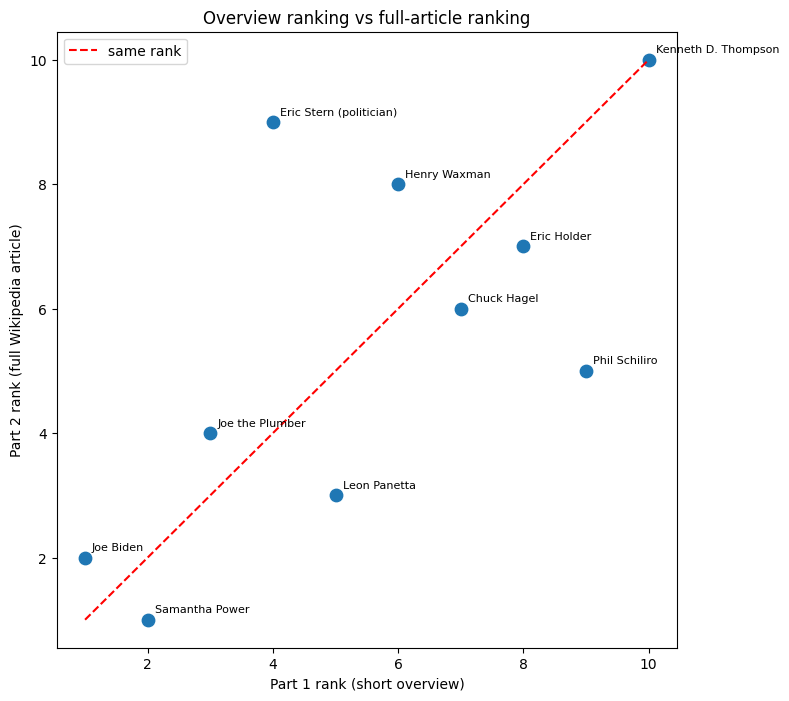

In [20]:
# Visualize the comparison: a point per person, overview-rank on x, wiki-rank
# on y. Points ON the diagonal dashed line ranked the same both ways; points
# far OFF it changed a lot between the two methods.
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(compare['overview_rank'], compare['wiki_rank'], s=80)

# Label each point with the person's name.
for _, row in compare.iterrows():
    # Skip labels where wiki_rank is missing (page not found).
    if pd.notna(row['wiki_rank']):
        ax.annotate(row['name'], (row['overview_rank'], row['wiki_rank']),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

# Diagonal reference line: y = x (same rank in both methods).
ax.plot([1, N_NEIGHBORS], [1, N_NEIGHBORS], 'r--', label='same rank')
ax.set_xlabel('Part 1 rank (short overview)')
ax.set_ylabel('Part 2 rank (full Wikipedia article)')
ax.set_title('Overview ranking vs full-article ranking')
ax.legend()
plt.show()


# Part 3 — Interactive: type or choose a name, get the 10 closest people

We wrap the Part 1 logic in a reusable function, then offer two ways to use it: a widget
(dropdown + text box) and a plain `input()` fallback that works in any environment.

In [21]:
# Reusable function: given a name, return the 10 closest people as a DataFrame.
# This is just Part 1's logic packaged so we can call it on ANY name on demand.
# Returns None and prints a hint if the name isn't found.
def find_closest_people(name, n=N_NEIGHBORS):
    # Locate the person's row.
    hits = people.index[people['name'] == name].tolist()
    if len(hits) == 0:
        print(f"'{name}' not found. Try the search box or check spelling.")
        return None
    idx = hits[0]

    # Nearest neighbors (n+1 to drop the person themselves).
    dist, ind = nn.kneighbors(tfidf[idx], n_neighbors=n + 1)
    ind = ind[0][1:]      # drop self
    dist = dist[0][1:]

    return pd.DataFrame({
        'rank': range(1, n + 1),
        'name': people.loc[ind, 'name'].values,
        'distance': dist.round(4),
    })

# Quick test using the reference person.
find_closest_people(REFERENCE_NAME)


,rank,name,distance
0,1,Joe Biden,0.6551
1,2,Samantha Power,0.6911
2,3,Joe the Plumber,0.7069
3,4,Eric Stern (politician),0.7092
4,5,Leon Panetta,0.7232
5,6,Henry Waxman,0.7309
6,7,Chuck Hagel,0.7380
7,8,Eric Holder,0.7492
8,9,Phil Schiliro,0.7499
9,10,Kenneth D. Thompson,0.7625


### Option A — `input()` version (works everywhere)

In [22]:
# Option A: simplest interactive form -- prompt for a name and show results.
# Run this cell, type a name at the prompt, and press Enter.
# (If running the whole notebook top-to-bottom pauses awkwardly here, you can
#  skip this cell and use the widget in Option B instead.)
typed_name = input("Enter a famous person's name: ")
display(find_closest_people(typed_name))


Enter a famous person's name: Barack Obama


,rank,name,distance
0,1,Joe Biden,0.6551
1,2,Samantha Power,0.6911
2,3,Joe the Plumber,0.7069
3,4,Eric Stern (politician),0.7092
4,5,Leon Panetta,0.7232
5,6,Henry Waxman,0.7309
6,7,Chuck Hagel,0.7380
7,8,Eric Holder,0.7492
8,9,Phil Schiliro,0.7499
9,10,Kenneth D. Thompson,0.7625


### Option B — widget version (dropdown + search box)

In [23]:
# Richer interactive form using ipywidgets. Two ways to pick a person:
#   1) Type part of a name in the search box to filter the dropdown.
#   2) Choose from the dropdown; results update automatically.
# If widgets don't render in your environment, use Option A above instead.
import ipywidgets as widgets
from IPython.display import display, clear_output

# A text box to filter names, a dropdown of matches, and an output area.
search_box = widgets.Text(description='Search:', placeholder='type part of a name')
name_dropdown = widgets.Dropdown(description='Person:', options=[])
out = widgets.Output()

# A sorted list of all names, used to populate the dropdown.
ALL_NAMES = sorted(people['name'].dropna().unique().tolist())

def update_dropdown(change):
    # Filter names by the search text (case-insensitive). Cap at 200 options so
    # the dropdown stays responsive on 40k+ names.
    query = search_box.value.strip().lower()
    if query == '':
        name_dropdown.options = ALL_NAMES[:200]
    else:
        matches = [nm for nm in ALL_NAMES if query in nm.lower()]
        name_dropdown.options = matches[:200]

def show_results(change):
    # When a dropdown selection is made, show that person's 10 closest people.
    with out:
        clear_output()
        if name_dropdown.value:
            display(find_closest_people(name_dropdown.value))

# Wire up the events.
search_box.observe(update_dropdown, names='value')
name_dropdown.observe(show_results, names='value')

# Initialize and display the widgets.
update_dropdown(None)
display(search_box, name_dropdown, out)


Text(value='', description='Search:', placeholder='type part of a name')

Dropdown(description='Person:', options=(' Renate Lorenz', '%C3%80lex Rigola', '%C3%81g%C3%BAsta Eva Erlendsd%…

Output()

---
### Presentation note
For the live demo, classmates will suggest a famous person who exists in the DBpedia set.
Type their name into the search box above (Option B) or run Option A and type it at the
prompt — the notebook will return the 10 closest individuals on the spot.